# Deteksi Kepala Janin pada Citra USG Menggunakan Pendekatan IRHT (Educational Implementation)

Notebook ini menyusun pipeline berdasarkan artikel:

**Prediksi Umur Janin Pada Citra USG Berdasarkan Ukuran BPD Dan HC Menggunakan IRHT**

Pipeline utama:

1. Input citra USG
2. Preprocessing
3. Edge detection (Canny)
4. Deteksi elips dengan pendekatan randomized/iterative Hough
5. Estimasi parameter elips
6. Pengukuran BPD dan HC
7. Konversi dan analisis hasil

Catatan:
- Implementasi IRHT penuh memiliki detail matematis dan optimasi yang kompleks.
- Notebook ini menyediakan implementasi pembelajaran yang merepresentasikan konsep utama: sampling titik edge, pembentukan kandidat elips, scoring berdasarkan kecocokan edge, dan pemilihan kandidat terbaik.


## 1. Import Library

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from pathlib import Path


## 2. Input Citra USG

Masukkan citra USG kepala janin.

Output tahap ini:
- citra grayscale
- visualisasi awal


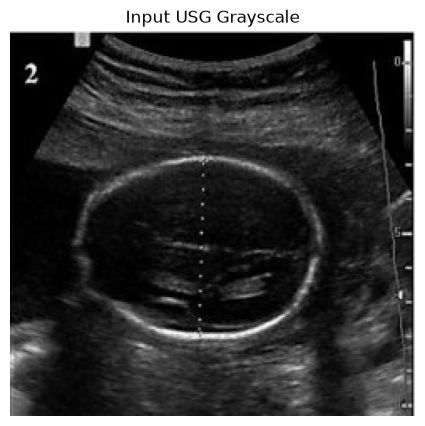

In [42]:
# Ganti path sesuai lokasi citra
image_path = "../janin.jpg"

img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError("Citra tidak ditemukan. Ganti image_path.")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,5))
plt.imshow(gray, cmap="gray")
plt.title("Input USG Grayscale")
plt.axis("off");


## 3. Preprocessing

Tahap preprocessing bertujuan mengurangi noise USG sebelum edge detection.

Operasi:
- Gaussian smoothing
- normalisasi intensitas


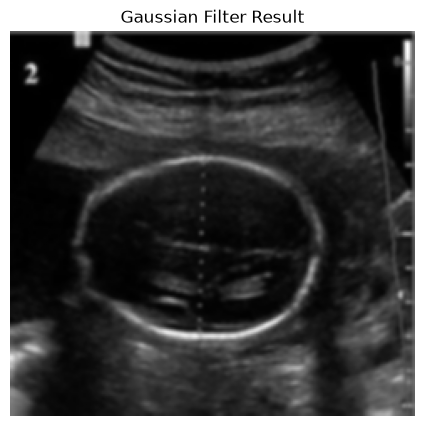

In [43]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(6,5))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Filter Result")
plt.axis("off");


## 4. Edge Detection menggunakan Canny

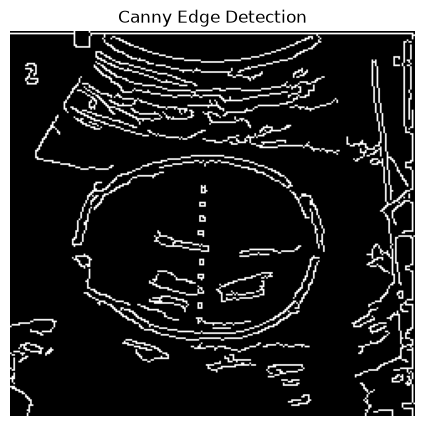

In [44]:
edges = cv2.Canny(
    blur,
    threshold1=50,
    threshold2=150
)

plt.figure(figsize=(6,5))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off");


## 5. Ekstraksi Edge Points

IRHT bekerja pada kumpulan titik edge:

\[
P = \{(x_1,y_1),(x_2,y_2),..., (x_n,y_n)\}
\]



Jumlah edge points: 5104


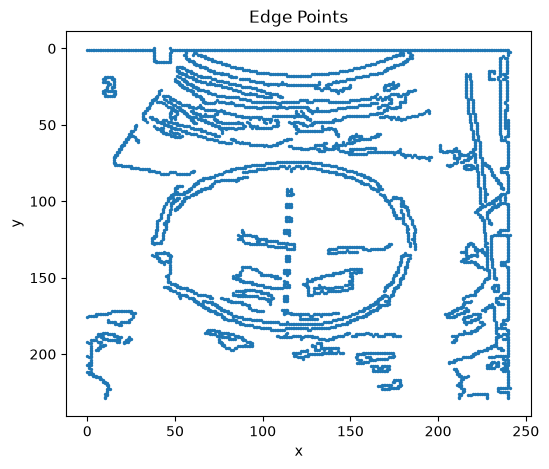

In [45]:
points = np.column_stack(np.where(edges > 0))

# batasi jumlah titik untuk eksperimen
max_points = 10000

if len(points) > max_points:
    points = points[np.random.choice(len(points), max_points, replace=False)]

print("Jumlah edge points:", len(points))

plt.figure(figsize=(6,5))
plt.scatter(points[:,1], points[:,0], s=2)
plt.gca().invert_yaxis()
plt.title("Edge Points")
plt.xlabel("x")
plt.ylabel("y");


# 6. Kandidat Ellipse

Representasi elips:

\[
(x_c,y_c,a,b,\theta)
\]

dimana:
- xc,yc = pusat elips
- a = semimajor axis
- b = semiminor axis
- theta = rotasi

Pada implementasi ini kita menggunakan:
- random sampling contour points
- OpenCV ellipse fitting sebagai estimator kandidat


In [46]:
def generate_candidate_ellipse(points, min_points=5):
    if len(points) < min_points:
        return None

    sample = points[
        np.random.choice(
            len(points),
            min_points,
            replace=False
        )
    ]

    sample = sample[:, ::-1].astype(np.int32)

    try:
        ellipse = cv2.fitEllipse(sample)
        return ellipse
    except:
        return None


## 7. Scoring Kandidat Elips

Kandidat dinilai berdasarkan jumlah edge yang dekat dengan kurva elips.

Semakin banyak edge yang bertepatan:
- semakin besar score
- semakin besar kemungkinan menjadi kepala janin


In [47]:
def ellipse_score(ellipse, edge_image, tolerance=2):
    canvas = np.zeros_like(edge_image)

    cv2.ellipse(
        canvas,
        ellipse,
        255,
        1
    )

    overlap = np.logical_and(
        canvas > 0,
        edge_image > 0
    )

    return np.sum(overlap)




## 8. Iterative Randomized Search (IRHT Approximation)

In [48]:
iterations = 200

best_score = 0
best_ellipse = None

for i in range(iterations):

    candidate = generate_candidate_ellipse(points)

    if candidate is not None:
        score = ellipse_score(candidate, edges)

        if score > best_score:
            best_score = score
            best_ellipse = candidate

print("Best score:", best_score)
print("Best ellipse:", best_ellipse)


Best score: 92
Best ellipse: ((132.49301147460938, 113.08646392822266), (171.5013885498047, 203.49644470214844), 121.94664764404297)


## 9. Visualisasi Best Ellipse

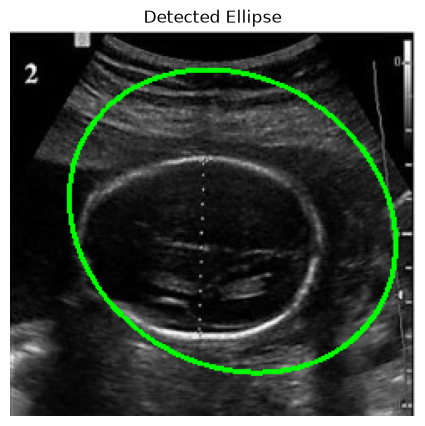

In [49]:
result = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

if best_ellipse is not None:
    cv2.ellipse(
        result,
        best_ellipse,
        (0,255,0),
        2
    )

plt.figure(figsize=(6,5))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Ellipse")
plt.axis("off");


## 10. Estimasi BPD dan HC

Dari elips diperoleh:
- major axis
- minor axis

Pendekatan artikel menggunakan hubungan geometris BPD dengan diameter kepala.

Pada implementasi ini:

\[
BPD pprox minor\ axis
\]

Konversi pixel ke mm membutuhkan informasi skala USG.


In [50]:
if best_ellipse is not None:

    center, axes, angle = best_ellipse

    major_axis = axes[0]
    minor_axis = axes[1]

    BPD_pixel = minor_axis

    print("Center:", center)
    print("Major axis pixel:", major_axis)
    print("Minor axis pixel:", minor_axis)
    print("Angle:", angle)
    print("Estimated BPD pixel:", BPD_pixel)

else:
    print("Ellipse belum ditemukan")


Center: (132.49301147460938, 113.08646392822266)
Major axis pixel: 171.5013885498047
Minor axis pixel: 203.49644470214844
Angle: 121.94664764404297
Estimated BPD pixel: 203.49644470214844


## 11. Catatan Pengembangan Lanjutan

Untuk penelitian yang lebih mendekati artikel:

1. Implementasikan IRHT matematis penuh:
   - sampling X1,X2,X3
   - tangent estimation
   - ellipse parameter conversion
   - accumulator

2. Tambahkan:
   - pixel-to-mm calibration
   - fetal growth reference model
   - evaluasi terhadap anotasi dokter

3. Untuk data USG modern:
   - gunakan U-Net segmentation
   - gunakan ellipse fitting sebagai tahap pengukuran biometrik
